In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [2]:
df = pd.read_csv(r"C:\Users\ASUS\Downloads\IRIS.csv")

In [3]:
df.head(10)

,ID,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
0,1,5.1,3.5,1.4,0.2,setosa
1,2,4.9,3.0,1.4,0.2,setosa
2,3,4.7,3.2,1.3,0.2,setosa
3,4,4.6,3.1,1.5,0.2,setosa
4,5,5.0,3.6,1.4,0.2,setosa
5,6,5.4,3.9,1.7,0.4,setosa
6,7,4.6,3.4,1.4,0.3,setosa
7,8,5.0,3.4,1.5,0.2,setosa
8,9,4.4,2.9,1.4,0.2,setosa
9,10,4.9,3.1,1.5,0.1,setosa


In [5]:
df['Species'].value_counts()


Species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

Câu lệnh mới FacetGrid: tạo một "lưới" (grid) để vẽ nhiều biểu đồ dựa trên các biến phân loại.

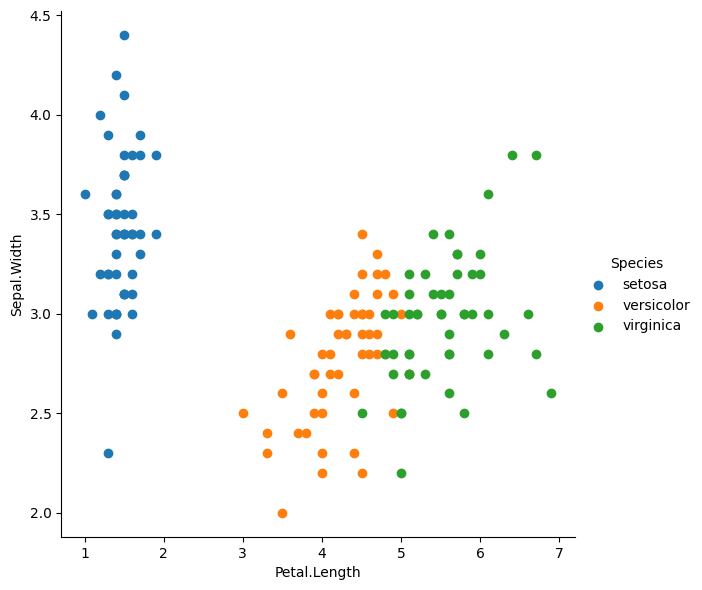

In [9]:
sns.FacetGrid(df, hue="Species",height=6).map(plt.scatter,"Petal.Length","Sepal.Width").add_legend()

<Axes: xlabel='Petal.Length', ylabel='Sepal.Width'>

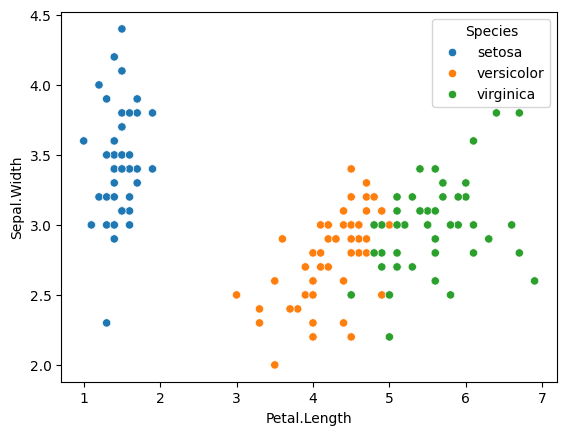

In [11]:
sns.scatterplot(data=df, x="Petal.Length", y="Sepal.Width",hue="Species")

Logistic Regression

In [12]:
df['Species'].unique()


array(['setosa', 'versicolor', 'virginica'], dtype=object)

In [13]:
Species_map = {'setora':0, 'versicolor':1,'virginica':2 } #Chuyển category sang number
df['Species'] = df['Species'].map(Species_map)

In [15]:
df.head(3)

,ID,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
0,1,5.1,3.5,1.4,0.2,NaN
1,2,4.9,3.0,1.4,0.2,NaN
2,3,4.7,3.2,1.3,0.2,NaN


In [28]:
df['Species']=df['Species'].fillna(0).astype('int')

In [29]:
df.head(3)

,ID,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
0,1,5.1,3.5,1.4,0.2,0
1,2,4.9,3.0,1.4,0.2,0
2,3,4.7,3.2,1.3,0.2,0


In [30]:
#Tạo input và output
x=df.drop(["Species","ID"],axis=1).values
y=df[['Species']].values


In [42]:
from sklearn.model_selection import train_test_split

In [44]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

test_size=0.2

Quy định tỷ lệ dữ liệu dành cho tập test.

0.2 nghĩa là 20% dữ liệu được dùng để test, còn 80% dùng để train
random_state=42

Là hạt giống (seed) cho bộ sinh số ngẫu nhiên khi chia dữ liệu.

Nếu bạn không đặt random_state, mỗi lần chạy train_test_split dữ liệu sẽ bị chia khác nhau → kết quả model có thể thay đổi.

Nếu bạn đặt random_state (ví dụ 42), thì lần nào chạy cũng chia dataset giống hệt nhau → giúp tái lập kết quả (reproducibility).

In [32]:
from sklearn.linear_model import LogisticRegression

In [33]:
model =LogisticRegression()

In [46]:
model.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [47]:
model.score(x,y) #độ chính xác

0.98

In [48]:
expected=y
predict=model.predict(x)
predict

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [49]:
from sklearn import metrics
print(metrics.classification_report(expected,predict))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       1.00      0.94      0.97        50
           2       0.94      1.00      0.97        50

    accuracy                           0.98       150
   macro avg       0.98      0.98      0.98       150
weighted avg       0.98      0.98      0.98       150



In [50]:
print(metrics.confusion_matrix(expected,predict))

[[50  0  0]
 [ 0 47  3]
 [ 0  0 50]]


In [53]:
ts =[[5.2,3.7,1.3,0.2]]

In [54]:
prediction = model.predict(ts)

In [56]:
print("Dự đoán loại:",prediction)

Dự đoán loại: [0]
